### Chapter 8: Computation on Arrays: Broadcasting

**8.1 Introducing Broadcasting**

Key Point: Rules that enable operations between arrays of different sizes

In [ ]:
import numpy as np

# 같은 크기의 배렬은 요소별 연산
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
print(a + b) 

# 크기가 다를 때에는? Broadcasting
print(a + 5)    # (5이 [5,5,5]로 자동 확장)

[5 6 7]
[5 6 7]


*브로드캐스팅의 마법:*  
* 5라는 스칼라 값이 자동으로 [5, 5, 5]로 확장됨  
* 실제 메모리 복사는 일어나지 않음! (가상적으로 확장)

**8.2 Rules of Broadcasting**

* 규칙 1: 차원 수가 다르면, 작은 쪽 앞에 1을 추가

In [ ]:
a = np.array([1, 2, 3])     # shape: (3,)
b = np.array([[1], [2]])    # shape: (2, 1)

# a의 shape (3,) → (1, 3)으로 변환 (앞에 1 추가)
# 결과 shape: (2, 3)

* 규칙 2: 각 차원의 크기가 1이면, 다른 쪽 크기에 맞춰 확장

In [ ]:
a = np.array([[1, 2, 3]])   # shape: (1, 3)
b = np.array([[4], [5]])    # shape: (2, 1)

# a: (1, 3) → (2, 3) (1이 2로 확장)
# b: (2, 1) → (2, 3) (1이 3으로 확장)
# 결과: (2, 3)

* 규칙 3: 크기가 다르고 둘 다 1이 아니면 에러

In [ ]:
a = np.array([1, 2, 3])     # shape: (3,)
b = np.array([4, 5])        # shape: (2,)

# a: (1, 3) → (1, 3)
# b: (1, 2) → (1, 2)
# 3 != 2 → 에러!
# a + b  # ValueError

**8.3 Broadcasting Examples**

* Example 1: 1D array + 2D array

In [8]:
import numpy as np

# shape(2, 3) array
M = np.ones((2, 3))
print("M shape:", M.shape)

# 1D array
a = np.arange(3)
print("a shape:", a.shape)

# broadcasting
result = M + a
print("Result shape:", result.shape)
print(result)

M shape: (2, 3)
a shape: (3,)
Result shape: (2, 3)
[[1. 2. 3.]
 [1. 2. 3.]]


* Example 2: 2D array + column vector

In [11]:
# column vector (3 rows 1 column)
col = np.arange(3).reshape(3, 1)
print("col shape:", col.shape)

# 3x3 array
M = np.ones((3, 3))

result = M + col
print(result)

col shape: (3, 1)
[[1. 1. 1.]
 [2. 2. 2.]
 [3. 3. 3.]]


* Example 3: Incompatible cases

In [14]:
M = np.ones((3, 2))
a = np.arange(3)

# result = M + a
# ValueError                                Traceback (most recent call last)
# Cell In[13], line 4
#       1 M = np.ones((3, 2))
#       2 a = np.arange(3)
#       3 
# ----> 4 result = M + a
#       5 print(result)
#       6 # M: (3, 2)
#       7 # a: (3,)

# M: (3, 2)
# a: (3,)
# a의 shape: (3,) → (1, 3)
# (3,2) vs (1,3) → 2 != 3 → 에러!
# M + a  # ValueError!

*Solution: Adjust with reshape*

In [15]:
a_col = a.reshape(3, 1)
result = M + a_col

print(result)

[[1. 1.]
 [2. 2.]
 [3. 3.]]


**8.4 Broadcasting in Practice**

1. Centering array

In [24]:
# 10 observations, 3 characteristics each
rng = np.random.default_rng(seed=1701)
X = rng.random((10, 3))

# Average of each column
col_mean = X.mean(axis=0)   # shape: (3,)

# Subtract average from each column using broadcasting
X_centered = X - col_mean

# Check: The average of a centered array is 0 (almost)
print(X_centered.mean(axis=0).round(10))

[ 0. -0.  0.]


2. Plotting a Two-Dimensional Function

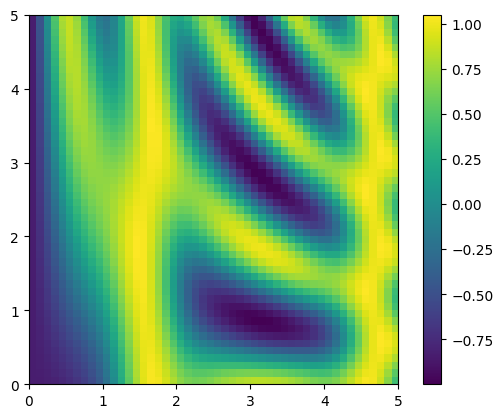

In [25]:
import matplotlib.pyplot as plt

# x, y 좌표 생성
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis] # 렬 벡터로

# 2D 함수 계산 (Broadcasting!)
z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

# Visualization
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5])
plt.colorbar()
plt.show()